In [1]:
import numpy as np
import numpy.typing as npt
import musdb
import os
import audio_effects
from IPython.display import Audio
import matplotlib.pyplot as plt
import peaq_numpy
from dataclasses import dataclass
import utils
import scipy.signal as sig

In [2]:

def dB20(x, eps=1e-6):
    return 20 * np.log(np.maximum(np.abs(x), eps))

@dataclass
class AudioSignal:
    signal:npt.ArrayLike
    samplerate:int

    def get_time(self):
        return np.arange(self.signal.shape[1])/self.samplerate
    
    def get_rfft(self, n=None):
        out = np.fft.rfft(self.signal, n=n)
        return out
    
    def get_rfftfreq(self, n=None):
        if n is None:
            n=self.signal.shape[1]
        out = np.fft.rfftfreq(n=n, d=1/self.samplerate)
        return out

In [3]:
musdb_path = os.path.normpath('C:/Users/pelad/Documents/Data/musdb18hq')
mus = musdb.DB(root=musdb_path, is_wav=True)


In [5]:
comp = audio_effects.compressor.CompressorBranching(
    threshold_dB=-10,
    ratio=4,
    attackTime_ms=5,
    releaseTime_ms=100,
    knee_dB=0,
    samplerate=41100
)

hpf = audio_effects.filters.equalizer.HighPass(
    f0 = 100,
    Q = .71,
    samplerate=44100
)

In [17]:

track_idx = 1

track = mus[track_idx]


in_sr = 48000
out_sr = 32000

#x = track.audio.T
#x = np.mean(x, axis=0, keepdims=True)
#x = x[:, :in_sr*15]
length_s = 4
t = np.arange(int(length_s*in_sr))/in_sr
x = sig.chirp(t=t, t1=length_s, f0 = 0, f1=in_sr//2, method='linear').reshape(1,-1)

x_pad = np.zeros((1, int((length_s+1)*in_sr)))
nstart = int(.5*in_sr)
nend = int(nstart+length_s*in_sr)
x_pad[:,nstart:nend] = x
x=x_pad

x = AudioSignal(signal=x, samplerate=in_sr)
#x = np.mean(x, axis=0)

RS = utils.resample.Resampler(in_samplerate=x.samplerate, out_samplerate=out_sr, taper_ratio=.1)

#y = hpf(x)
y = AudioSignal(signal=RS(x.signal), samplerate=out_sr)

        

# plt.plot(t, x)
# plt.plot(t, y)

# plt.xlim(1, 2)

display(Audio(data=x.signal[0], rate=x.samplerate))
display(Audio(data=y.signal[0], rate=y.samplerate))

len(mus)


150

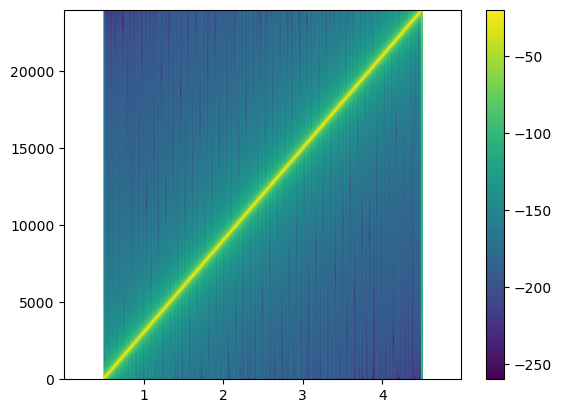

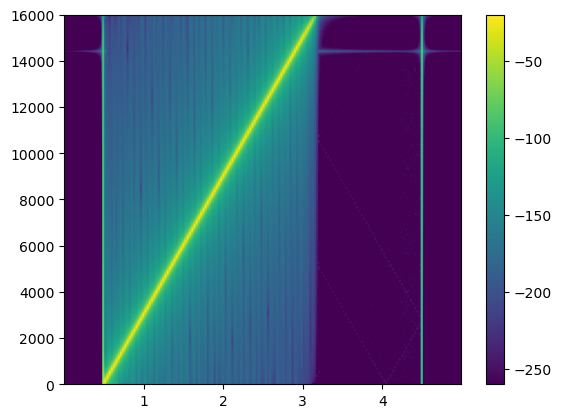

In [18]:
n_fft = 1024
plt.specgram(x=x.signal[0], Fs=x.samplerate,vmin=-260, vmax=-20, NFFT=n_fft, scale='dB')
plt.colorbar()
plt.show()
plt.specgram(x=y.signal[0], Fs=y.samplerate,vmin=-260, vmax=-20, NFFT=n_fft, scale='dB')
plt.colorbar()
plt.show()
